<a href="https://colab.research.google.com/github/Jiyoung169/Uber_Review_Analysis/blob/main/Analysis_of_Uber_User_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Comprehensive Analysis of Uber Customer Sentiment and Service Quality Trends (2025)**
* BAN200OBB: Sentiment Analysis and Text Mining
* Group3: Veronica Hoo, Vincent Le, Ivan Keov, Jiyoung Choi and Harsimran Singh


### **Project_Group3: Project Workflow & Role Distribution**
* Data Integration & Cleaning: Veronica
* Text Preprocessing: Vincent and Ivan
* Exploratory Data Analysis (EDA): Jiyoung and Harsimran

In [1]:
# Library Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import kagglehub
import os

import tensorflow as tf
import keras
import re
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

!pip install google_play_scraper
from google_play_scraper import Sort, reviews
from datetime import datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.8 MB/s eta 0:00:00


**Webscraping: Veronica Hoo**

In [2]:
#Scrape user reviews from Google Play Store
app_id = 'com.ubercab'
all_reviews = []
continuation_token = None
target_date = datetime(2025, 1, 1)

while True:
    result, continuation_token = reviews(
        app_id,
        lang='en',
        country='us',
        sort=Sort.NEWEST,
        count=10000,
        continuation_token=continuation_token
    )
    all_reviews.extend(result)


    last_date = result[-1]['at']
    print(last_date)

    if last_date < target_date:
        break

    if not continuation_token:
        break

2026-03-08 20:25:10
2026-02-15 12:13:34
2026-01-24 06:52:00
2026-01-01 06:13:51
2025-12-10 04:12:12
2025-11-20 17:58:20
2025-11-03 08:58:49
2025-10-09 11:51:08
2025-09-15 14:25:22
2025-08-20 07:07:33
2025-07-31 07:52:57
2025-07-12 17:28:12
2025-06-27 09:29:00
2025-06-06 08:39:48
2025-05-16 12:01:30
2025-04-28 12:42:21
2025-04-10 03:39:54
2025-03-21 19:17:24
2025-02-28 14:11:12
2025-02-06 09:28:19
2025-01-17 04:21:21
2024-12-27 03:12:49


In [3]:
# Convert to pandas dataframe
df_uber_reviews = pd.DataFrame(all_reviews)

# Change review 'at' column to datetime format
df_uber_reviews['at'] = pd.to_datetime(df_uber_reviews['at'])

# Filter to show reviews from 2025 only
df_reviews_2025 = df_uber_reviews[
    (df_uber_reviews['at'] >= '2025-01-01') &
    (df_uber_reviews['at'] <= '2025-12-31')
].copy()

# Make sure that filtering was applied correctly
print(f"Original number of records scraped: {len(df_uber_reviews)}")
print(f"Number of records just from 2025: {len(df_reviews_2025)}")

Original number of records scraped: 220000
Number of records just from 2025: 177146


In [4]:
# Check that filtering (to 2025 data only) was completed successfully
df_reviews_2025.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
40588,6a6eeb34-cfce-4025-acfc-7a706abfe577,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"great driver , knows the area and safe.",5,0,4.609.10005,2025-12-30 23:50:16,None,NaT,4.609.10005
40589,74f095a6-837c-4d33-bda4-5e8dcc22c311,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The worst app of all,1,0,4.609.10005,2025-12-30 23:46:19,None,NaT,4.609.10005
40590,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,seriously!!! are the people behind this app ju...,1,2,4.609.10005,2025-12-30 23:34:18,None,NaT,4.609.10005
40591,72a88391-cae5-4f2a-9e89-01a69237e605,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Uber bringing the night life back to Winnipeg ...,5,0,4.609.10005,2025-12-30 23:32:53,None,NaT,4.609.10005
40592,eaadc7fe-4313-404c-8f39-3db80b4b56a8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Every time I use this app, there's no cars in ...",1,0,4.609.10005,2025-12-30 23:32:38,None,NaT,4.609.10005


In [5]:
# Get the metadata of our filtered dataframe
df_reviews_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177146 entries, 40588 to 217733
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              177146 non-null  object        
 1   userName              177146 non-null  object        
 2   userImage             177146 non-null  object        
 3   content               177146 non-null  object        
 4   score                 177146 non-null  int64         
 5   thumbsUpCount         177146 non-null  int64         
 6   reviewCreatedVersion  148399 non-null  object        
 7   at                    177146 non-null  datetime64[ns]
 8   replyContent          386 non-null     object        
 9   repliedAt             386 non-null     datetime64[ns]
 10  appVersion            148399 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 16.2+ MB


In [6]:
first_200_reviews = df_reviews_2025.head(200)
first_200_reviews.to_csv('first_200_reviews_2025.csv', index=False)
print('Successfully exported the first 200 reviews to first_200_reviews_2025.csv')

# Display the head of the exported data to verify
display(first_200_reviews.head())

Successfully exported the first 200 reviews to first_200_reviews_2025.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
40588,6a6eeb34-cfce-4025-acfc-7a706abfe577,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"great driver , knows the area and safe.",5,0,4.609.10005,2025-12-30 23:50:16,None,NaT,4.609.10005
40589,74f095a6-837c-4d33-bda4-5e8dcc22c311,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The worst app of all,1,0,4.609.10005,2025-12-30 23:46:19,None,NaT,4.609.10005
40590,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,seriously!!! are the people behind this app ju...,1,2,4.609.10005,2025-12-30 23:34:18,None,NaT,4.609.10005
40591,72a88391-cae5-4f2a-9e89-01a69237e605,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Uber bringing the night life back to Winnipeg ...,5,0,4.609.10005,2025-12-30 23:32:53,None,NaT,4.609.10005
40592,eaadc7fe-4313-404c-8f39-3db80b4b56a8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Every time I use this app, there's no cars in ...",1,0,4.609.10005,2025-12-30 23:32:38,None,NaT,4.609.10005


**Data Cleaning: Veronica Hoo**

In [7]:
# Drop the columns 'userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', and 'repliedAt'
df_reviews_2025.drop(columns=['userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', 'repliedAt'], inplace=True)

# Check to see if columns were dropped
df_reviews_2025.head()

,reviewId,content,score,thumbsUpCount,at
40588,6a6eeb34-cfce-4025-acfc-7a706abfe577,"great driver , knows the area and safe.",5,0,2025-12-30 23:50:16
40589,74f095a6-837c-4d33-bda4-5e8dcc22c311,The worst app of all,1,0,2025-12-30 23:46:19
40590,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,seriously!!! are the people behind this app ju...,1,2,2025-12-30 23:34:18
40591,72a88391-cae5-4f2a-9e89-01a69237e605,Uber bringing the night life back to Winnipeg ...,5,0,2025-12-30 23:32:53
40592,eaadc7fe-4313-404c-8f39-3db80b4b56a8,"Every time I use this app, there's no cars in ...",1,0,2025-12-30 23:32:38


In [8]:
# Check for duplicate rows
duplicates = df_reviews_2025.duplicated(subset=['reviewId','content','score','thumbsUpCount','at']).sum()
print(duplicates)

# RESULT: No duplicate rows

0


In [9]:
# Find sum of missing values per column
df_reviews_2025.isnull().sum()

# RESULT: No missing values

,0
reviewId,0
content,0
score,0
thumbsUpCount,0
at,0


In [10]:
# Basic summary statistics:
# just gives info about score and thumbsUpCount and indicates if outliers are present
df_reviews_2025.describe()

# RESULT: No identified outliers

,score,thumbsUpCount,at
count,177146.000000,177146.000000,177146
mean,3.823468,0.723296,2025-06-29 19:27:52.749669632
min,1.000000,0.000000,2025-01-01 00:01:42
25%,2.000000,0.000000,2025-04-03 15:03:18.249999872
50%,5.000000,0.000000,2025-06-29 10:09:09
75%,5.000000,0.000000,2025-09-27 13:39:33.750000128
max,5.000000,8700.000000,2025-12-30 23:50:16
std,1.719208,33.970978,NaN



 **Text Preprocessing: Vincent and Ivan**



In [11]:
# Define cleaning function

nltk.download('wordnet')
nltk.download('omw-1.4')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def advanced_clean_and_tokenize(text):


    # Convert to lowercase
    lowercase_text = text.lower()

    # Identify words with 2 or more characters
    tokens = re.findall(r'\b\w\w+\b', lowercase_text)

    # Filter out stop words to focus on meaningful content
    clean_tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in ENGLISH_STOP_WORDS
    ]

    return " ".join(clean_tokens)

# Apply preprocessing
df_reviews_2025['clean_content'] = df_reviews_2025['content'].apply(advanced_clean_and_tokenize)



[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [12]:
# Sentiment Labeling for Supervised Learning

df_reviews_2025['label'] = df_reviews_2025['score'].map({5:1, 4:1, 2:0, 1:0})
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


In [13]:
# Preprocessing and Labeling
print(df_reviews_2025[['content', 'clean_content', 'label']].head())

                                                 content  \
40588            great driver , knows the area and safe.   
40589                               The worst app of all   
40590  seriously!!! are the people behind this app ju...   
40591  Uber bringing the night life back to Winnipeg ...   
40592  Every time I use this app, there's no cars in ...   

                                           clean_content  label  
40588                        great driver know area safe      1  
40589                                          worst app      0  
40590  seriously people app just genuinely stupid ord...      0  
40591  uber bringing night life winnipeg safe cost ef...      1  
40592  time use app car area taxi service disaster ub...      0  


**Exploratory Data Analysis(EDA): Jiyoung and Harsimran**

In [14]:
# Check the distribution of scores
score_distribution = df_reviews_2025['score'].value_counts().sort_index()
print(score_distribution)


score
1     43516
2      4765
4     10465
5    113603
Name: count, dtype: int64


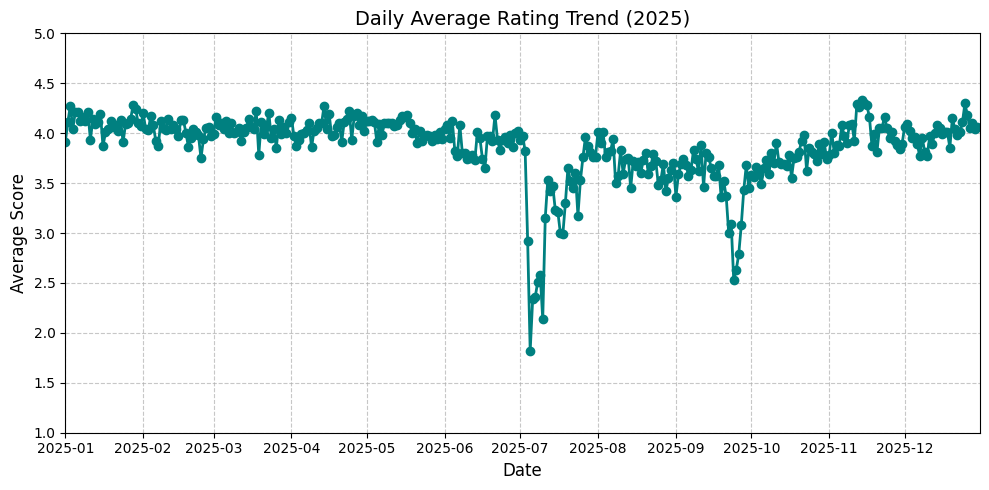

In [15]:

# Group by date from the 'at' column and calculate the mean score
daily_mean_score = df_reviews_2025.groupby(df_reviews_2025['at'].dt.date)['score'].mean()

# Visualization Setup
plt.figure(figsize=(10, 5))
daily_mean_score.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))


plt.title('Daily Average Rating Trend (2025)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

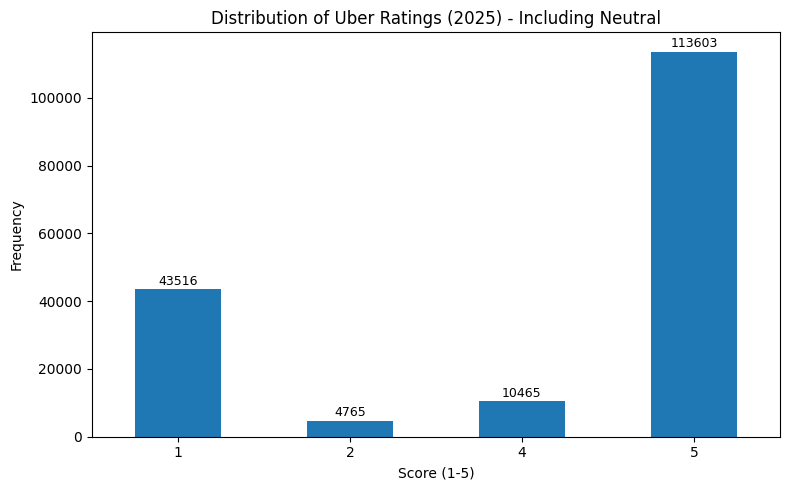

In [16]:

# Visualize Score Distribution
df_reviews_2025['label'] = df_reviews_2025['score'].map({
    5: 2, # Positive
    4: 2, # Positive
    3: 1, # Neutral
    2: 0, # Negative
    1: 0  # Negative
})

# Drop rows only if the label is truly missing
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


plt.figure(figsize=(8,5))
counts = df_reviews_2025['score'].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('Distribution of Uber Ratings (2025) - Including Neutral')
plt.xlabel('Score (1-5)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

# Adding data labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

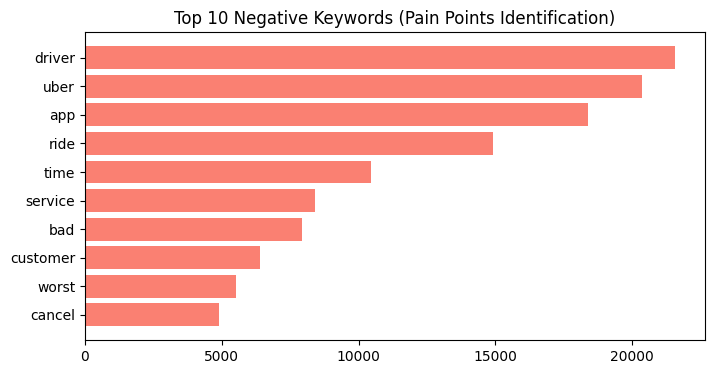

In [17]:
# Key Insights: Top 10 Keywords in Negative Reviews
# Analyzing the most frequent complaints (pain points)
negative_reviews = df_reviews_2025[df_reviews_2025['label'] == 0]['clean_content']
all_neg_words = " ".join(negative_reviews).split()
most_common_neg = Counter(all_neg_words).most_common(10)

words, counts = zip(*most_common_neg)
plt.figure(figsize=(8, 4))
plt.barh(words, counts, color='salmon')
plt.title('Top 10 Negative Keywords (Pain Points Identification)')
plt.gca().invert_yaxis()
plt.show()

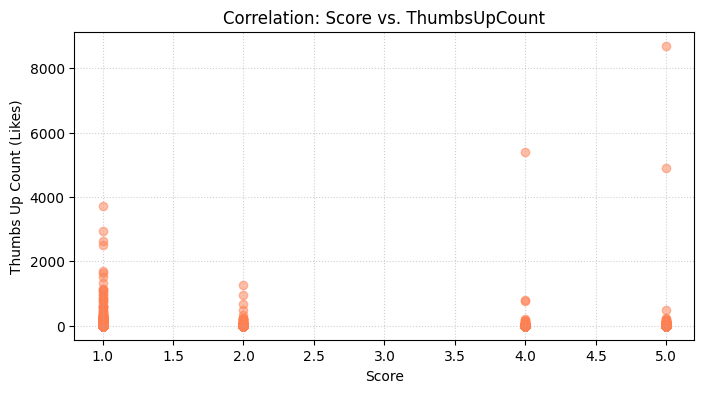

In [18]:
# Correlation Analysis: Score vs. ThumbsUpCount
# Analyze if impactful complaints (high likes) are associated with lower scores
plt.figure(figsize=(8, 4))
plt.scatter(df_reviews_2025['score'], df_reviews_2025['thumbsUpCount'], alpha=0.5, color='coral')
plt.title('Correlation: Score vs. ThumbsUpCount')
plt.xlabel('Score')
plt.ylabel('Thumbs Up Count (Likes)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [19]:
# Summary Statistics
print(df_reviews_2025[['score', 'thumbsUpCount']].describe())

               score  thumbsUpCount
count  172349.000000  172349.000000
mean        3.846387       0.709839
std         1.737396      33.839138
min         1.000000       0.000000
25%         1.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000    8700.000000
